In [1]:
#1. OBSERVAMOS LAS DIMENSIONES DE LOS DATOS
import h5py as h5
import numpy as np
import time
import pandas as pd
import os
import json
# 1. Configuración de la ruta
ruta_maestra = r"C:\Users\MSI\Downloads\Proyecto_Fluidos_AI\datos_procesados\process_data.h5"

ruta_carpeta_guardar= r"C:\Users\MSI\Downloads\Proyecto_Fluidos_AI\datos_procesados\runtranformerprueba"
# Crear la carpeta si no existe
os.makedirs(ruta_carpeta_guardar, exist_ok=True)

with h5.File(ruta_maestra, 'r') as f:
    # Leemos las dimensiones de las tres componentes
    grupo = f['data_analisis']
    u_shape = grupo['u_fluc'].shape
    v_shape = grupo['v_fluc'].shape
    w_shape = grupo['w_fluc'].shape

# Verificación de seguridad: las 3 matrices deben ser idénticas en tamaño
assert u_shape == v_shape == w_shape, "¡Error crítico! Las dimensiones de U, V y W no coinciden."

num_tiempos = u_shape[0]
dim_y = u_shape[1] #number of lines of probes
dim_z = u_shape[2]
total_puntos_espaciales = dim_y * dim_z

print("--- ESTADÍSTICAS DEL DATASET MULTICANAL ---")
print(f"Total de instantes de tiempo: {num_tiempos}")
print(f"Malla espacial: {dim_y} x {dim_z} = {total_puntos_espaciales} puntos")
print(f"Canales de velocidad: 3 (U, V, W)")
print(f"Total de datos numéricos a procesar: {num_tiempos * total_puntos_espaciales * 3:,}")

# 2. CÁLCULO DE DIVISIONES (Splits temporales)
# Primero separamos el 20% para el examen final (test/resultados)
indice_test = int(num_tiempos * 0.8)

# Del 80% restante, separamos otro 20% para validación (0.8 * 0.8 = 0.64)
indice_val = int(indice_test * 0.8)

print("\n--- REPARTO DEL TIEMPO ---")
print(f"1. Entrenamiento (64%): Pasos 0 al {indice_val}")
print(f"2. Validación    (16%): Pasos {indice_val} al {indice_test}")
print(f"3. Resultados    (20%): Pasos {indice_test} al {num_tiempos}")

--- ESTADÍSTICAS DEL DATASET MULTICANAL ---
Total de instantes de tiempo: 106000
Malla espacial: 7 x 288 = 2016 puntos
Canales de velocidad: 3 (U, V, W)
Total de datos numéricos a procesar: 641,088,000

--- REPARTO DEL TIEMPO ---
1. Entrenamiento (64%): Pasos 0 al 67840
2. Validación    (16%): Pasos 67840 al 84800
3. Resultados    (20%): Pasos 84800 al 106000


In [2]:
#2. PREPARACIÓN DE LOS DATOS PARA EL MODELO
import torch
from torch.utils.data import TensorDataset, DataLoader 
import os

def obtener_o_crear_datasets(ruta_maestra, train_dataset_pt_v, val_dataset_pt_v, stats_pt_v, linea_idy):
    """
    Comprueba si existen los archivos procesados. 
    Si existen, los carga. Si no, ejecuta la lógica de 5760 columnas y los guarda.
    """
    
    # 1. Comprobar si AMBOS archivos ya existen en el disco
    if os.path.exists(train_dataset_pt_v) and os.path.exists(val_dataset_pt_v) and os.path.exists(stats_pt_v):
        print(f"📦 Archivos detectados. Cargando datasets desde {train_dataset_pt_v}...")
        train_ds = torch.load(train_dataset_pt_v,weights_only=False)
        val_ds = torch.load(val_dataset_pt_v,weights_only=False)
        stats = torch.load(stats_pt_v, weights_only=False)
        return train_ds, val_ds, stats


    else:

        with h5.File(ruta_maestra, 'r') as f:
            # 1. Suponiendo que 'datos' es tu matriz original de forma (106000, 7, 288)
            matriz_base = f['data_analisis']['v_fluc'][:, linea_idy, :]  # Forma: (106000, 288)

            # 2. Definimos las dimensiones y el tamaño de los paquetes
            chunk_size = 5050
            num_chunks = len(matriz_base) // chunk_size  # 106000 // 5050 = 20

            # Recortamos la matriz para que el tamaño sea múltiplo exacto
            matriz_recortada = matriz_base[:num_chunks * chunk_size, :]

            # 3. Transformación de las dimensiones
           
            trozos = []
            for i in range(num_chunks):
                inicio = i * chunk_size
                fin = (i + 1) * chunk_size
                pedazo = matriz_recortada[inicio:fin, :]
                trozos.append(pedazo)

            # 3. Los "pegamos" de lado (horizontalmente)
            # matriz_final pasará a ser (5050, 288 * 20) = (5050, 5760)
            matriz_final = np.hstack(trozos)

            print("Forma de la matriz final:", matriz_final.shape) # Imprimirá (5050, 5760)

        # 4. Separación final en Input y Output
        input_limit = 5000

        # Conjunto de entrada (5000 x 5760)
        X_data_raw = matriz_final[:input_limit, :]

        # Conjunto de salida (50 x 5760)
        y_data_raw = matriz_final[input_limit : input_limit + (matriz_final.shape[0] - input_limit), :]

        print("Forma de X_data (Input):", X_data_raw.shape)
        print("Forma de y_data (Output):", y_data_raw.shape)
        
        #Normalizamos los datos usando la media y desviación de X_data_raw (¡MUY IMPORTANTE!)
        media_X = np.mean(X_data_raw)
        std_X = np.std(X_data_raw)

        #Guardamos las estadísticas para usarlas en la normalización de los datos de validación y test
        stats = {
            'media': media_X,
            'std': std_X
        }

        X_data = (X_data_raw - media_X) / std_X
        y_data = (y_data_raw - media_X) / std_X

        # 5. DIVISIÓN 80/20 DE LAS COLUMNAS (5760)
        # ==========================================
        total_columnas = X_data.shape[1] # 5760
        split_idx = int(total_columnas * 0.8) # 4608

        # 1. Creamos una lista de índices y la barajamos aleatoriamente
        # Usamos una semilla (seed) para que la aleatoriedad sea igual siempre que ejecutes el código
        np.random.seed(42) 
        indices_barajados = np.random.permutation(total_columnas)


        # 2. Separamos esos índices en los grupos de entrenamiento y validación
        train_indices = indices_barajados[:split_idx] # Los primeros 4608 números aleatorios
        val_indices = indices_barajados[split_idx:]   # Los 1152 restantes


        # Partimos las matrices por las columnas
        X_train_np = X_data[:, train_indices]  # Forma: (5000, 4608)
        X_val_np = X_data[:, val_indices]    # Forma: (5000, 1152)

        y_train_np = y_data[:, train_indices]  # Forma: (50, 4608)
        y_val_np = y_data[:, val_indices]    # Forma: (50, 1152)

        # ==========================================
        # 6. CONVERSIÓN A TENSORES Y TRANSPOSICIÓN (.T)
        # ==========================================
        # ¡MUY IMPORTANTE!: PyTorch necesita que el número de "ejemplos" esté en la 
        # PRIMERA dimensión para poder hacer los lotes (batches). 
        # Por eso transponemos (.T) las matrices antes de convertirlas a tensores.

        # X pasará de (5000, 4608) a (4608, 5000)
        train_features = torch.tensor(X_train_np.T, dtype=torch.float32).unsqueeze(-1) 
        val_features = torch.tensor(X_val_np.T, dtype=torch.float32).unsqueeze(-1)

        # Y pasará de (50, 4608) a (4608, 50)
        train_labels = torch.tensor(y_train_np.T, dtype=torch.float32).unsqueeze(-1) 
        val_labels = torch.tensor(y_val_np.T, dtype=torch.float32).unsqueeze(-1)

        #Organizamos las matrices en DataLoaders para entrenamiento y validación
        train_dataset = TensorDataset(train_features, train_labels)
        val_dataset = TensorDataset(val_features, val_labels)

        #Guardamos los datasets para usarlos en el entrenamiento de la red neuronal
        torch.save(train_dataset, train_dataset_pt_v)
        torch.save(val_dataset, val_dataset_pt_v)
        torch.save(stats, stats_pt_v)

        return train_dataset, val_dataset, stats

# Seleccionamos la línea o matriz que nos interesa 
linea_idy=2

# --- MODO DE USO ---
# Define los nombres de tus archivos
f_train = 'train_dataset_tf_pr.pt'
f_val = 'val_dataset_tf_pr.pt'
f_stats = 'norm_stats_tf_pr.pt'

# Llamas a la función
train_dataset, val_dataset, stats_norm = obtener_o_crear_datasets(ruta_maestra, f_train, f_val, f_stats, linea_idy)

train_loader= DataLoader(train_dataset, batch_size=64, shuffle=True,drop_last=False, num_workers=0, pin_memory=True)
val_loader= DataLoader(val_dataset, batch_size=64, shuffle=False,drop_last=False, num_workers=0, pin_memory=True)

📦 Archivos detectados. Cargando datasets desde train_dataset_tf_pr.pt...


In [3]:
#3. DEFINIMOS NUESTRO MODELO TRANSFORMER


import torch
import torch.nn as nn
import math

class MultiHeadEasyAttention(nn.Module):
    def __init__(self, seq_len, input_dim, d_model, num_heads=4):
        super().__init__()
        assert d_model % num_heads == 0, "d_model debe ser divisible por num_heads"
        self.num_heads = num_heads
        self.head_dim = d_model // num_heads
        
        # Tensor \alpha para múltiples cabezas: (h, p, p)
        self.alpha = nn.Parameter(torch.empty(num_heads, seq_len, seq_len))
        nn.init.xavier_uniform_(self.alpha)
        
        # Proyección compartida W_V para todas las cabezas
        self.W_v = nn.Linear(input_dim, d_model, bias=False)

    def forward(self, x):
        b, p, _ = x.size() # b=Batch, p=seq_len
        
        # 1. Proyectar valores: (Batch, seq_len, d_model)
        V = self.W_v(x)
        
        # 2. Separar en múltiples cabezas: (Batch, seq_len, num_heads, head_dim)
        V = V.view(b, p, self.num_heads, self.head_dim)
        # Transponer para emparejar con alpha: (Batch, num_heads, seq_len, head_dim)
        V = V.permute(0, 2, 1, 3)
        
        # 3. Multiplicar cada cabeza de \alpha con su bloque V correspondiente
        # 'hij' (alpha), 'bhjd' (V) -> 'bhid' (salida por cabeza)
        out = torch.einsum('hij,bhjd->bhid', self.alpha, V)
        
        # 4. Concatenar las cabezas de vuelta al tamaño d_model
        out = out.permute(0, 2, 1, 3).contiguous().view(b, p, -1)
        return out
    

class EasyTransformerBlock(nn.Module):
    def __init__(self, seq_len, d_model=64, num_heads=4):
        super().__init__()
        self.attention = MultiHeadEasyAttention(seq_len, d_model, d_model, num_heads)
        self.norm1 = nn.LayerNorm(d_model)
        expansion_factor = 4
        self.feed_forward = nn.Sequential(
            nn.Linear(d_model, d_model * expansion_factor), 
            nn.ReLU(),
            nn.Linear(d_model * expansion_factor, d_model)
        )
        self.norm2 = nn.LayerNorm(d_model)

    def forward(self, x):
        attn_out = self.attention(x)
        x = self.norm1(x + attn_out)
        ff_out = self.feed_forward(x)
        x = self.norm2(x + ff_out)
        return x

class EasyFluidPredictor(nn.Module):
    def __init__(self, seq_len=500, pred_len=50, input_dim=1, d_model=64, num_heads=4):
        super().__init__()
        self.input_dim = input_dim
        self.input_proj = nn.Linear(input_dim, d_model)
        self.easy_transformer = EasyTransformerBlock(seq_len, d_model, num_heads)
        self.output_proj = nn.Linear(d_model, pred_len)

    def forward(self, x):
        x = self.input_proj(x)
        x = self.easy_transformer(x)
        x_last = x[:, -1, :] 
        out = self.output_proj(x_last)
        if len(out.shape) < 3 and out.shape[-1] :#!= self.input_dim: #
            out = out.unsqueeze(-1)
        #print("Salida del modelo (antes de unsqueeze):", out.shape)  # Debug: Verificar forma antes de unsqueeze
        #print("Salida del modelo (después de unsqueeze):", out.unsqueeze(-1).shape)  # Debug: Verificar forma después de unsqueeze
        return out

In [4]:
#4. ENTRENAMOS NUESTRA RED NEURONAL


# 🚨 AUTODETECCIÓN DE DIMENSIONES 🚨
# train_dataset[0] devuelve la primera tupla (X, Y)
ejemplo_x, ejemplo_y = train_dataset[0]

num_heads = 8  # Puedes ajustar este número según la capacidad de tu GPU y la complejidad que quieras

d_model = 64  # Dimensión interna del modelo (puedes ajustar este número para hacerlo más pequeño o más grande)

input_dim = ejemplo_x.shape[1]  # Cada punto espacial es un canal de entrada

pred_len =  ejemplo_y.shape[0]  # Número de pasos futuros a predecir

seq_len = ejemplo_x.shape[0]  # Número de pasos pasados que el modelo usará para predecir

print('Dimensiones detectadas:')
print(f'  - Secuencia de entrada (X): {seq_len} pasos')
print(f'  - Secuencia de salida (Y): {pred_len} pasos')
print(f'  - Dimensiones de entrada: {input_dim}')

lr=0.0001  # Tasa de aprendizaje para el optimizador





modelo = EasyFluidPredictor(seq_len=seq_len, pred_len=pred_len, input_dim=input_dim, d_model=d_model, num_heads=num_heads)

criterio = nn.MSELoss() # Error Cuadrático Medio
optimizador = torch.optim.Adam(modelo.parameters(), lr=lr)
# ==========================================
# 1. CONFIGURACIÓN DEL HARDWARE
# ==========================================
# Detectar si hay Tarjeta Gráfica (GPU) disponible. Si no, usará la CPU.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Entrenando en el dispositivo: {device}")

# Movemos el modelo a la tarjeta gráfica (o lo dejamos en CPU)
modelo.to(device)

# ==========================================
# 2. PARÁMETROS DEL ENTRENAMIENTO
# ==========================================
epocas = 150  # Número de veces que la IA verá TODO el dataset completo
tek=time.time()


historial_train_loss = []
historial_val_loss = []
#Creamos para guadar el mejor modelo basado en la pérdida de validación
best_val_loss = float('inf')  # Empezamos con "infinito" para que cualquier pérdida sea menor
ruta_mejor_modelo = ruta_carpeta_guardar+'/mejor_modelo_ia.pt'

print("\n🚀 ¡Iniciando el entrenamiento de la Red Neuronal!")
print("-" * 60)

# ==========================================
# 3. EL BUCLE PRINCIPAL
# ==========================================
for epoca in range(epocas):
    print(f"\n📊 Época {epoca+1}/{epocas}")
    tic = time.time()
    # --- FASE DE ENTRENAMIENTO ---
    modelo.train()  # Ponemos el modelo en modo "aprender"
    train_loss_acumulada = 0.0
    
    for batch_idx, (x_batch, y_batch) in enumerate(train_loader):
        print(f"  Procesando lote {batch_idx+1}/{len(train_loader)}", end='\r')
        # Movemos los datos a la GPU (o CPU)
        x_batch = x_batch.to(device)
        #print('input',x_batch.shape)
        y_batch = y_batch.to(device)
        #print('output',y_batch.shape)
        # a) Reiniciamos los gradientes (borramos la memoria de la pasada anterior)
        optimizador.zero_grad()
        
        # b) Pasada hacia adelante (Forward): La IA intenta predecir el futuro
        predicciones = modelo(x_batch)

        
        # c) Calculamos el error (Loss): Comparamos la predicción con la realidad
        loss = criterio(predicciones, y_batch)
        
        # d) Pasada hacia atrás (Backward): Calculamos cómo corregir los errores
        loss.backward()
        
        # e) Actualizamos los pesos (El aprendizaje real ocurre aquí)
        optimizador.step()
        
        train_loss_acumulada += loss.item()

        
        
    # Calculamos el error medio de esta época
    avg_train_loss = train_loss_acumulada / len(train_loader)
    historial_train_loss.append(avg_train_loss)
    
    
    # --- FASE DE VALIDACIÓN ---
    # Aquí la IA NO aprende, solo hace un "examen" con datos que no ha visto
    modelo.eval()  # Ponemos el modelo en modo "examen"
    val_loss_acumulada = 0.0
    
    # Apagamos el cálculo de gradientes para ahorrar memoria y no aprender sin querer
    with torch.no_grad():
        for x_val, y_val in val_loader:
            x_val = x_val.to(device)
            y_val = y_val.to(device)
            
            predicciones_val = modelo(x_val)
            loss_val = criterio(predicciones_val, y_val)
            val_loss_acumulada += loss_val.item()
            
    # Calculamos el error medio del examen
    avg_val_loss = val_loss_acumulada / len(val_loader)
    historial_val_loss.append(avg_val_loss)
    toc = time.time()

    # --- Supongamos que aquí termina tu validación de la época ---
# avg_val_loss es el promedio de pérdida de esta época en validación

    if avg_val_loss < best_val_loss:
        print(f"⭐ ¡Nuevo récord! La pérdida bajó de {best_val_loss:.6f} a {avg_val_loss:.6f}. Guardando...")
        
        # Actualizamos el récord
        best_val_loss = avg_val_loss
        
        # Creamos un diccionario con todo lo importante
        checkpoint = {
            'epoch': epoca,
            'model_state_dict': modelo.state_dict(),  # Los "pesos" de la IA
            'optimizer_state_dict': optimizador.state_dict(),
            'loss': best_val_loss,
            'stats': stats_norm # Incluimos las estadísticas de normalización que creamos antes
        }
        
        # Guardamos el archivo (esto sobrescribirá el anterior, quedándote siempre con el mejor)
        torch.save(checkpoint, ruta_mejor_modelo)

    # Imprimimos el progreso al final de cada época
    print(f"Época [{epoca+1:02d}/{epocas}] | Train Loss (MSE): {avg_train_loss:.6f} | Val Loss: {avg_val_loss:.6f}")
    print(f"Tiempo de la época: {toc - tic:.2f} segundos")

print("-" * 60)
print("✅ ¡Entrenamiento completado!")
tac=time.time()


Dimensiones detectadas:
  - Secuencia de entrada (X): 5000 pasos
  - Secuencia de salida (Y): 50 pasos
  - Dimensiones de entrada: 1
Entrenando en el dispositivo: cuda

🚀 ¡Iniciando el entrenamiento de la Red Neuronal!
------------------------------------------------------------

📊 Época 1/150
⭐ ¡Nuevo récord! La pérdida bajó de inf a 1.008258. Guardando...
Época [01/150] | Train Loss (MSE): 1.124908 | Val Loss: 1.008258
Tiempo de la época: 153.54 segundos

📊 Época 2/150
⭐ ¡Nuevo récord! La pérdida bajó de 1.008258 a 0.737573. Guardando...
Época [02/150] | Train Loss (MSE): 0.797135 | Val Loss: 0.737573
Tiempo de la época: 131.98 segundos

📊 Época 3/150
⭐ ¡Nuevo récord! La pérdida bajó de 0.737573 a 0.636294. Guardando...
Época [03/150] | Train Loss (MSE): 0.632007 | Val Loss: 0.636294
Tiempo de la época: 132.78 segundos

📊 Época 4/150
⭐ ¡Nuevo récord! La pérdida bajó de 0.636294 a 0.589577. Guardando...
Época [04/150] | Train Loss (MSE): 0.560558 | Val Loss: 0.589577
Tiempo de la époc

In [5]:
# ==========================================
# 5. GUARDADO DE METADATOS Y RESULTADOS (JSON)
# ==========================================
import json
import time

# Creamos el diccionario adaptado a la arquitectura Transformer
metadata = {}

# 1. Arquitectura del Transformer (Los "músculos" del modelo)
metadata['model_type'] = "Easy Attention Transformer"
metadata['input_dim'] = input_dim         # Dimensión de entrada (velocidad u)
metadata['seq_len'] = seq_len             # Ventana de pasado (lookback)
metadata['pred_len'] = pred_len             # Ventana de futuro (prediction)
metadata['d_model'] = d_model              # Espacio latente interno
metadata['num_heads'] = num_heads             # Número de cabezas de atención

# 2. Hiperparámetros de entrenamiento
metadata['learning_rate'] = lr    # El LR que pusimos en el Adam
metadata['epochs_planned'] = epocas   # Total de épocas solicitadas

# 3. Estadísticas de rendimiento (El "marcador")
metadata['best_val_loss'] = best_val_loss
metadata['salto_ventana_deslizante'] = 'No hay ventana deslizante'
metadata['train_time_seconds'] = tac - tek
metadata['train_time_minutes'] = (tac - tek) / 60
metadata['date_time'] = time.strftime("%Y-%m-%d %H:%M:%S")

# 4. Información del Dataset y Hardware
metadata['linea_idy'] = linea_idy      # La sonda/línea analizada (ej: 2)
metadata['num_train_samples'] = len(train_loader.dataset)
metadata['num_val_samples'] = len(val_loader.dataset)
metadata['gpu_name'] = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None"

# 5. Estadísticas de Normalización (¡Crucial para usar el modelo después!)
# Guardamos media y std para poder des-normalizar predicciones sin cargar el .pt
metadata['norm_stats'] = {
    'media': float(stats_norm['media']),
    'std': float(stats_norm['std'])
}

# Guardar el diccionario en un archivo JSON bien formateado
ruta_json = ruta_carpeta_guardar + '/hyperparams_transformer.json'

with open(ruta_json, 'w', encoding='utf-8') as f:
    json.dump(metadata, f, ensure_ascii=False, indent=4)

print(f"✅ Metadatos guardados correctamente en: {ruta_json}")

✅ Metadatos guardados correctamente en: C:\Users\MSI\Downloads\Proyecto_Fluidos_AI\datos_procesados\runtranformerprueba/hyperparams_transformer.json


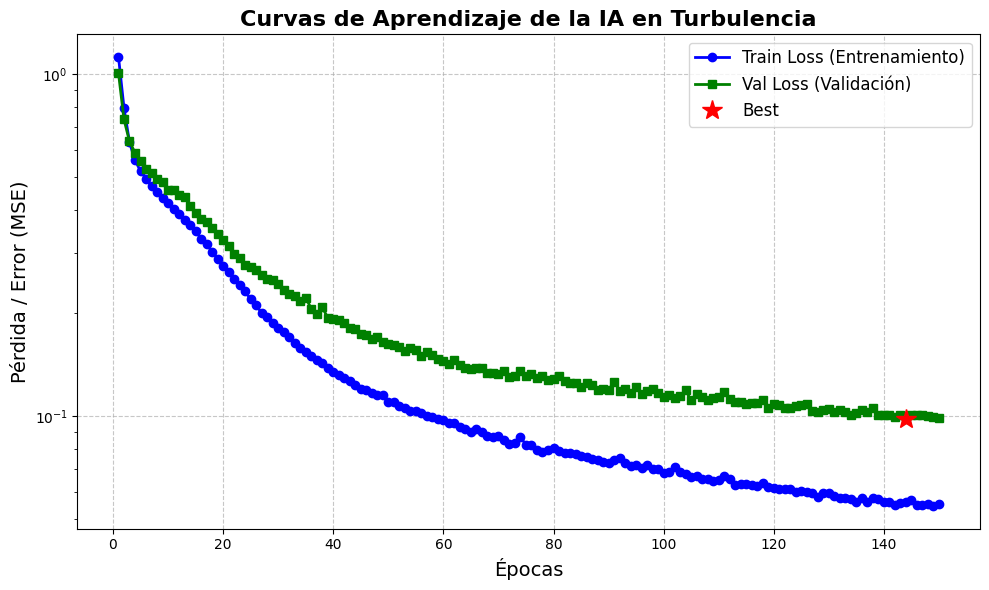

In [6]:
# 6. VISUALIZACIÓN DE RESULTADOS
import matplotlib.pyplot as plt
import torch # Por si acaso no estaba importado en esta celda
import torch.nn as nn
import numpy as np
import pandas as pd
'''
print("Calculando el Baseline Ingenuo para la gráfica...")

# ==========================================
# 1. CÁLCULO DEL BASELINE (La predicción "estúpida")
# ==========================================
val_loss_ingenua_acumulada = 0.0
criterio_baseline = nn.MSELoss()

with torch.no_grad():
    for x_val, y_val in val_loader:
        x_val = x_val.to(device)
        y_val = y_val.to(device)
        
        # 1. Cogemos el último paso de la ventana de entrada (forma: [64])
        ultimo_valor = x_val[:, -1] 
        
        # 2. Le añadimos una dimensión y lo repetimos 50 veces para igualar al futuro
        # Forma final: [64, 50]
        prediccion_estupida = ultimo_valor.unsqueeze(1).repeat(1, y_val.shape[1])
        
        # 3. Ahora sí podemos comparar 50 predicciones idénticas con 50 realidades
        loss_estupida = criterio_baseline(prediccion_estupida, y_val)
        val_loss_ingenua_acumulada += loss_estupida.item()

baseline_val_loss = val_loss_ingenua_acumulada / len(val_loader)
print(f"🚨 Valor del Baseline (MSE): {baseline_val_loss:.6f}")
'''
# ==========================================
# 2. DIBUJAMOS LA GRÁFICA
# ==========================================
plt.figure(figsize=(10, 6))

# Eje X: Número de épocas (de 1 a N)
epocas_x = range(1, len(historial_train_loss) + 1)

#Convertimos en arrays
historial_val_loss_np = np.array(historial_val_loss)
epocas_x_np = np.array(epocas_x)

# Trazamos las curvas de la IA
plt.semilogy(epocas_x, historial_train_loss, 'b-o', label='Train Loss (Entrenamiento)', linewidth=2)
plt.semilogy(epocas_x, historial_val_loss, 'g-s', label='Val Loss (Validación)', linewidth=2)
plt.semilogy(epocas_x[historial_val_loss_np.argmin()], historial_val_loss_np.min(), '*r', label='Best', markersize=15)

# Trazamos la línea infranqueable del baseline
#plt.axhline(y=baseline_val_loss, color='r', linestyle='--', linewidth=2, label='Baseline (Persistencia)')

# Estética y etiquetas
plt.title('Curvas de Aprendizaje de la IA en Turbulencia', fontsize=16, fontweight='bold')
plt.xlabel('Épocas', fontsize=14)
plt.ylabel('Pérdida / Error (MSE)', fontsize=14)
plt.legend(fontsize=12, loc='upper right')
plt.grid(True, linestyle='--', alpha=0.7)
#plt.xticks(epocas_x) # Fuerza a que el eje X muestre números enteros

# Ajustamos márgenes y mostramos
plt.tight_layout()
plt.savefig(ruta_carpeta_guardar+'/curvas_aprendizaje.png', dpi=300) # Guardamos la figura en alta resolución
plt.show()


df = pd.DataFrame()
df['epoch']=range(1, len(historial_train_loss)+1)
df['train_loss']=historial_train_loss
df['val_loss']=historial_val_loss
df.to_csv(ruta_carpeta_guardar+'/historial_perdidas.csv', index=False, sep=',', float_format='%.6e')